In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, classification_report,
                            confusion_matrix)
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import warnings
from sklearn.preprocessing import LabelEncoder
warnings.filterwarnings('ignore')

In [21]:
# ── Cell: Feature Engineering ─────────────────────────────────────────────────
print("=" * 60)
print("FEATURE ENGINEERING: Scenario Feature Vectors")
print("=" * 60)


df_feat = pd.read_csv('Datasets/SharedResponses_combined.csv')

# ── 1. Character group aggregates ─────────────────────────────────────────────
# Total humans vs animals on each side of the scenario
human_cols  = ['Man','Woman','Pregnant','Stroller','OldMan','OldWoman',
               'Boy','Girl','Homeless','LargeWoman','LargeMan','Criminal',
               'MaleExecutive','FemaleExecutive','FemaleAthlete','MaleAthlete',
               'FemaleDoctor','MaleDoctor']
animal_cols = ['Dog', 'Cat']

df_feat['TotalHumans']  = df_feat[human_cols].sum(axis=1).astype('int16')
df_feat['TotalAnimals'] = df_feat[animal_cols].sum(axis=1).astype('uint8')

# Vulnerable group: children, pregnant, elderly
df_feat['VulnerableCount'] = df_feat[['Pregnant','Stroller','OldMan','OldWoman',
                                       'Boy','Girl']].sum(axis=1).astype('uint8')

# High status group: executives, doctors, athletes
df_feat['HighStatusCount'] = df_feat[['MaleExecutive','FemaleExecutive',
                                       'MaleAthlete','FemaleAthlete',
                                       'FemaleDoctor','MaleDoctor']].sum(axis=1).astype('uint8')

# Low status / stigmatised group
df_feat['LowStatusCount'] = df_feat[['Homeless','Criminal']].sum(axis=1).astype('uint8')

print(f"  [created]  TotalHumans, TotalAnimals, VulnerableCount, "
      f"HighStatusCount, LowStatusCount")

# ── 2. Differential features (trade-off signals) ──────────────────────────────
# These directly capture the tension between the two options in each scenario

# Lives at stake: how many characters are involved total
df_feat['DiffLivesSaved'] = df_feat['DiffNumberOFCharacters'].astype('int16')
# (already exists but rename for clarity — positive = more saved by acting)

# Is the scenario human vs animal
df_feat['IsHumanVsAnimal'] = (
    (df_feat['TotalHumans'] > 0) & (df_feat['TotalAnimals'] > 0)
).astype('uint8')

# Is intervention required to save the larger group
df_feat['InterventionSavesMore'] = (
    (df_feat['Intervention'] == True) & (df_feat['DiffNumberOFCharacters'] > 0)
).astype('uint8')

# Lawful context: was the pedestrian crossing legally (green light)
df_feat['LawfulPedestrian'] = (df_feat['CrossingSignal'] == 1).astype('uint8')

# Scenario involves purely pedestrians on both sides (no passengers)
df_feat['PurelyPedestrian'] = df_feat['PedPed'].astype('uint8')

print(f"  [created]  DiffLivesSaved, IsHumanVsAnimal, InterventionSavesMore, "
      f"LawfulPedestrian, PurelyPedestrian")

# ── 3. Respondent bias features ───────────────────────────────────────────────
# Interaction between respondent traits and scenario properties
# These help the model learn how user background moderates decisions

df_feat['AgeXVulnerable']   = (df_feat['Review_age_scaled'] *
                                df_feat['VulnerableCount']).astype('float32')
df_feat['PoliticalXStatus'] = (df_feat['Review_political_scaled'] *
                                df_feat['HighStatusCount']).astype('float32')
df_feat['ReligiousXLives']  = (df_feat['Review_religious_scaled'] *
                                df_feat['TotalHumans']).astype('float32')

print(f"  [created]  AgeXVulnerable, PoliticalXStatus, ReligiousXLives")

# ── 4. Define final feature matrix and target ──────────────────────────────────
exclude_cols = {
    'ExtendedSessionID',   # identifier
    'Saved',               # target
    'DiffNumberOFCharacters',  # replaced by DiffLivesSaved
    'Intervention',        # encoded into InterventionSavesMore
    'PedPed',              # encoded into PurelyPedestrian
    'CrossingSignal',      # encoded into LawfulPedestrian
}

feature_cols = [c for c in df_feat.columns if c not in exclude_cols]
target_col   = 'Saved'

X = df_feat[feature_cols]
y = df_feat[target_col].astype('int8')

print(f"\n{'─'*60}")
print(f"Feature matrix   : {X.shape}")
print(f"Target           : '{target_col}'  |  classes: {y.value_counts().to_dict()}")
print(f"Class balance    : {y.mean()*100:.1f}% Saved=1")
print(f"\nFeature columns ({len(feature_cols)}):")
for i, col in enumerate(feature_cols):
    print(f"  {i+1:>2}. {col:35s} {str(X[col].dtype):>10}")

FEATURE ENGINEERING: Scenario Feature Vectors
  [created]  TotalHumans, TotalAnimals, VulnerableCount, HighStatusCount, LowStatusCount
  [created]  DiffLivesSaved, IsHumanVsAnimal, InterventionSavesMore, LawfulPedestrian, PurelyPedestrian
  [created]  AgeXVulnerable, PoliticalXStatus, ReligiousXLives

────────────────────────────────────────────────────────────
Feature matrix   : (8834024, 47)
Target           : 'Saved'  |  classes: {1: 4451280, 0: 4382744}
Class balance    : 50.4% Saved=1

Feature columns (47):
   1. Barrier                                   bool
   2. DefaultChoiceIsOmission                   bool
   3. NumberOfCharacters                       int64
   4. Man                                      int64
   5. Woman                                    int64
   6. Pregnant                                 int64
   7. Stroller                                 int64
   8. OldMan                                   int64
   9. OldWoman                                 int64
  10.

In [23]:
print("=" * 60)
print("MODELING: Logistic Regression vs Random Forest")
print("=" * 60)

# ── 1. Train/test split ───────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"  Train size : {len(X_train):,}  ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Test size  : {len(X_test):,}   ({len(X_test)/len(X)*100:.0f}%)")
print(f"  Class balance (train) — Saved=1: {y_train.mean()*100:.1f}%")

# ── 2. Define models ──────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        solver='saga',       # fastest solver for large datasets
        n_jobs=-1,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,        # capped to avoid overfitting on 8M rows
        min_samples_leaf=50, # smooths decision boundaries
        n_jobs=-1,
        random_state=42
    ),
}

# ── 3. Train & evaluate ───────────────────────────────────────────────────────
results = {}

for name, model in models.items():
    print(f"\n{'─'*60}")
    print(f"  Training: {name} ...")
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0
    print(f"  Done in {train_time:.1f}s")

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred, zero_division=0),
        'Recall'    : recall_score(y_test, y_pred, zero_division=0),
        'F1'        : f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC'   : roc_auc_score(y_test, y_proba),
    }
    results[name] = metrics

    print(f"\n  {'Metric':<12} {'Score':>8}")
    print(f"  {'─'*22}")
    for metric, score in metrics.items():
        print(f"  {metric:<12} {score:>8.4f}")

    print(f"\n  Classification Report:\n")
    print(classification_report(y_test, y_pred, target_names=['Not Saved', 'Saved']))

# ── 4. Side-by-side comparison ────────────────────────────────────────────────
print(f"\n{'═'*60}")
print(f"  MODEL COMPARISON")
print(f"{'═'*60}")
print(f"  {'Metric':<12}", end="")
for name in models:
    print(f"  {name:>22}", end="")
print()
print(f"  {'─'*58}")
for metric in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']:
    print(f"  {metric:<12}", end="")
    for name in models:
        score = results[name][metric]
        print(f"  {score:>22.4f}", end="")
    print()

winner = max(results, key=lambda m: results[m]['F1'])
print(f"\n  Best model by F1: {winner}")

# ── 5. Feature importance (Random Forest only) ────────────────────────────────
print(f"\n{'─'*60}")
print(f"  FEATURE IMPORTANCES (Random Forest — top 15)")
print(f"{'─'*60}")
rf_model = models['Random Forest']
importances = (
    pd.Series(rf_model.feature_importances_, index=feature_cols)
    .sort_values(ascending=False)
    .head(15)
)
for feat, imp in importances.items():
    bar = '█' * int(imp * 400)
    print(f"  {feat:35s} {imp:.4f}  {bar}")

# ── 6. Logistic Regression coefficients ───────────────────────────────────────
print(f"\n{'─'*60}")
print(f"  TOP COEFFICIENTS (Logistic Regression — top 15 by magnitude)")
print(f"{'─'*60}")
lr_model = models['Logistic Regression']
coefs = (
    pd.Series(lr_model.coef_[0], index=feature_cols)
    .abs()
    .sort_values(ascending=False)
    .head(15)
)
for feat, coef in coefs.items():
    direction = '+' if lr_model.coef_[0][feature_cols.index(feat)] > 0 else '-'
    print(f"  {direction} {feat:33s} {coef:.4f}")

MODELING: Logistic Regression vs Random Forest
  Train size : 7,067,219  (80%)
  Test size  : 1,766,805   (20%)
  Class balance (train) — Saved=1: 50.4%

────────────────────────────────────────────────────────────
  Training: Logistic Regression ...


c:\Users\hallv\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  Done in 100.7s

  Metric          Score
  ──────────────────────
  Accuracy       0.6787
  Precision      0.6879
  Recall         0.6633
  F1             0.6754
  ROC-AUC        0.7345

  Classification Report:

              precision    recall  f1-score   support

   Not Saved       0.67      0.69      0.68    876549
       Saved       0.69      0.66      0.68    890256

    accuracy                           0.68   1766805
   macro avg       0.68      0.68      0.68   1766805
weighted avg       0.68      0.68      0.68   1766805


────────────────────────────────────────────────────────────
  Training: Random Forest ...
  Done in 595.8s

  Metric          Score
  ──────────────────────
  Accuracy       0.7372
  Precision      0.7380
  Recall         0.7417
  F1             0.7398
  ROC-AUC        0.8107

  Classification Report:

              precision    recall  f1-score   support

   Not Saved       0.74      0.73      0.73    876549
       Saved       0.74      0.74      0.74 

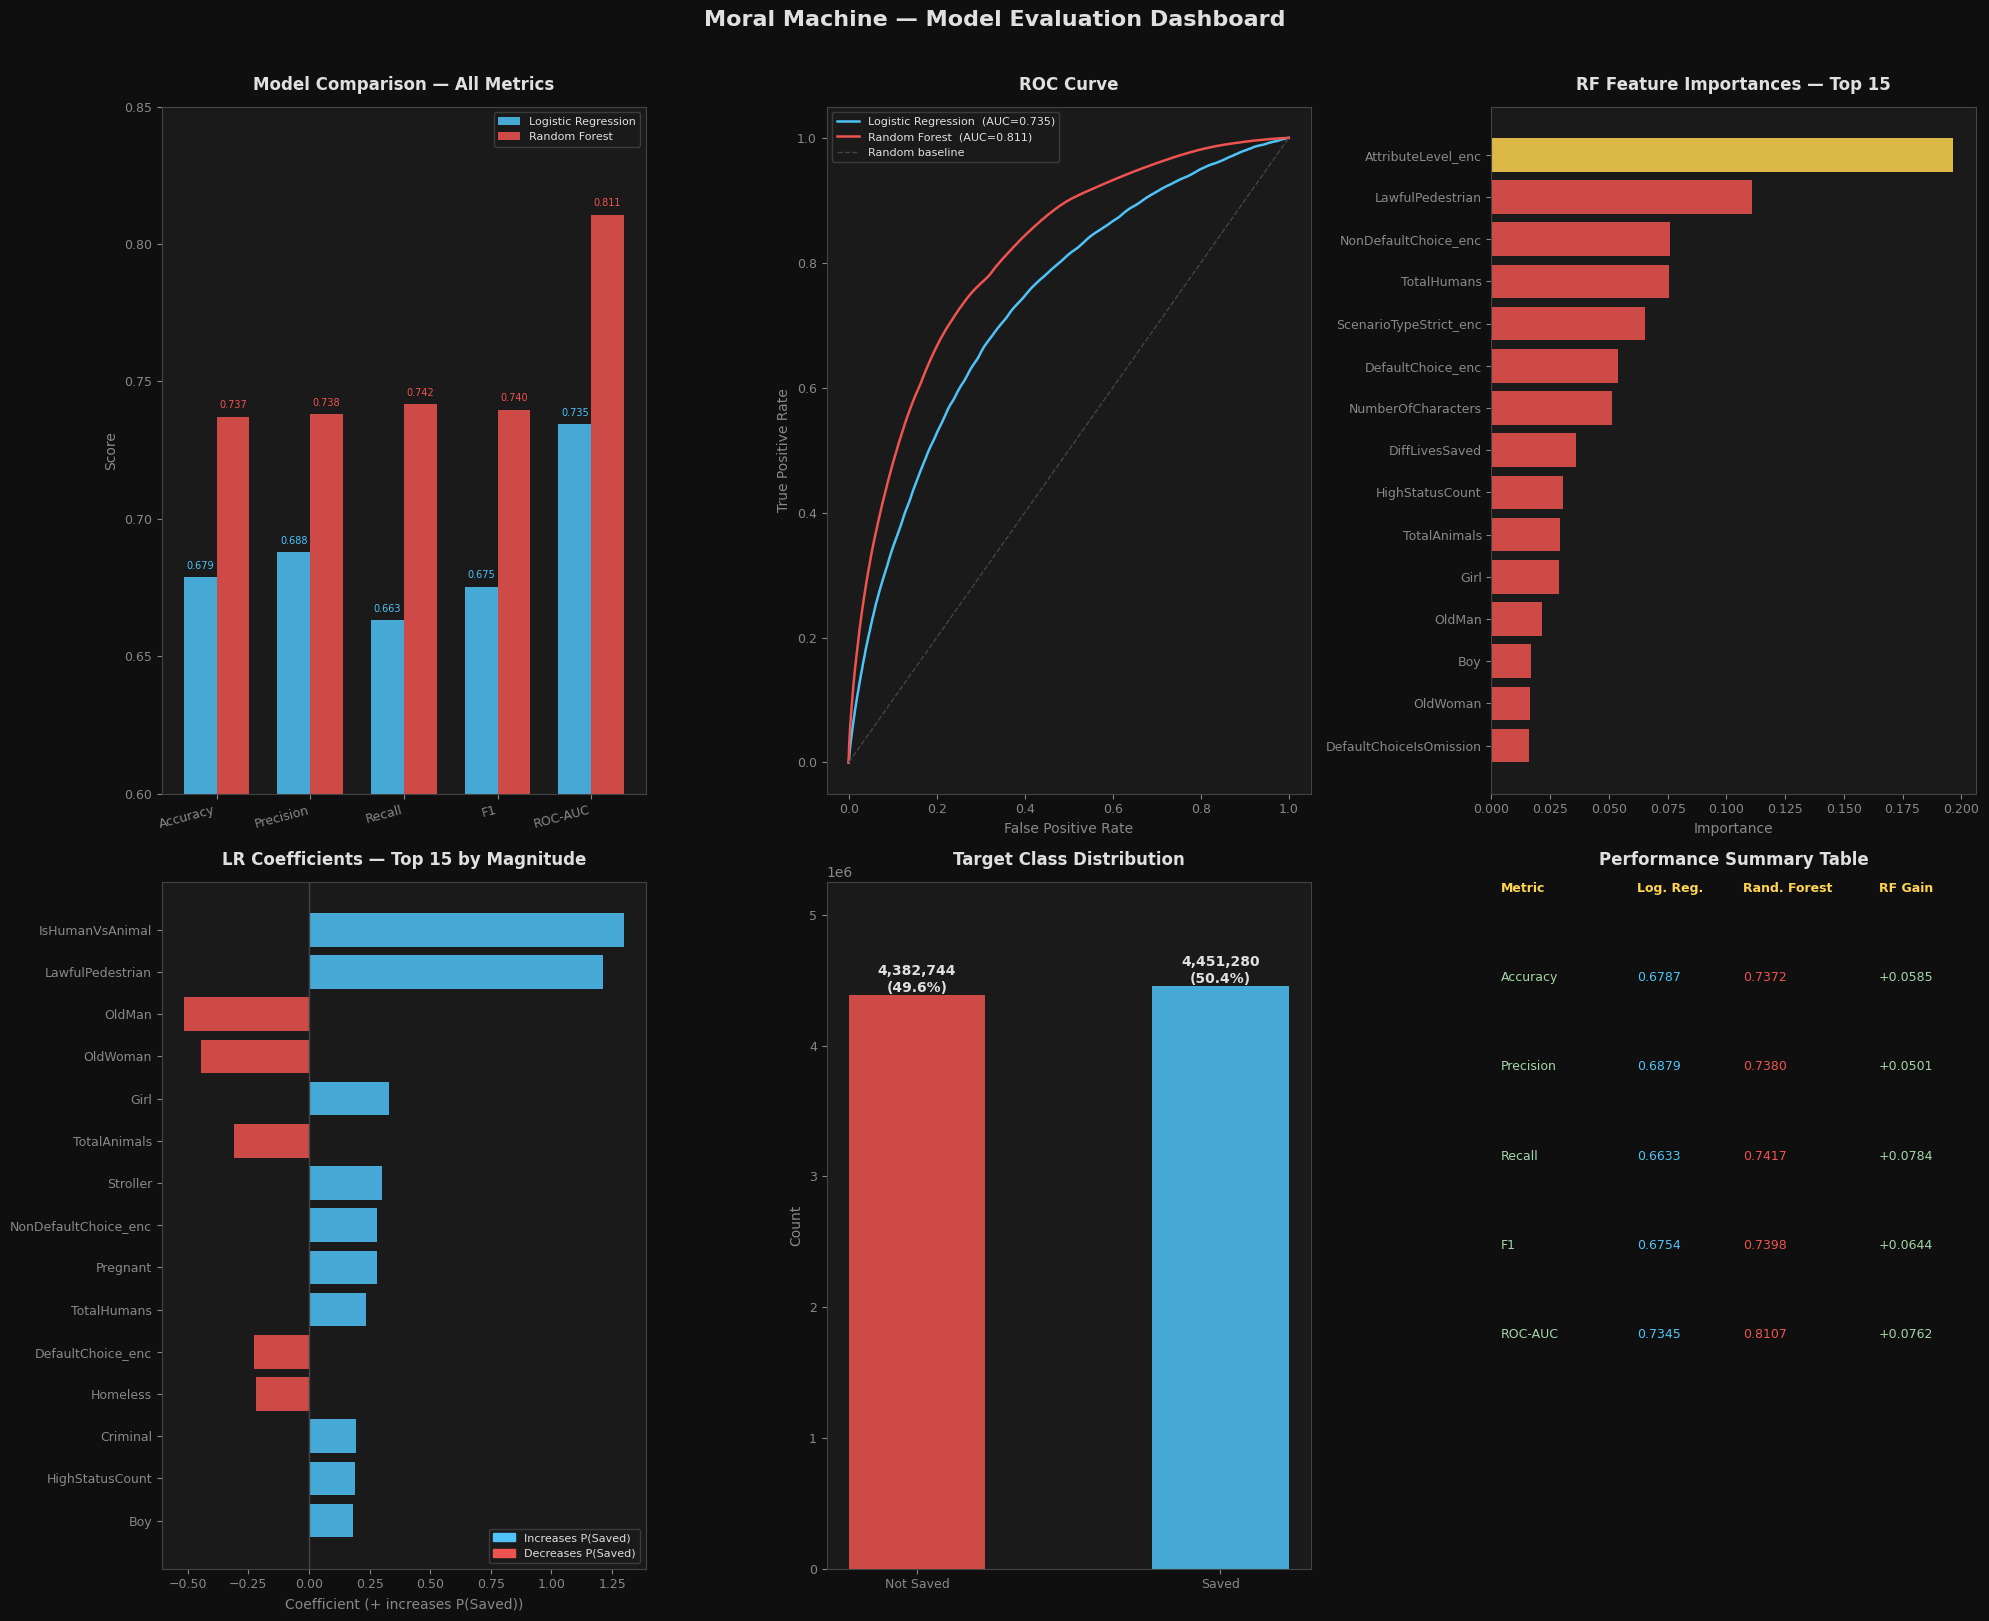

Saved → Images/model_evaluation.png


In [27]:
fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('#0f0f0f')

DARK   = '#0f0f0f'
PANEL  = '#1a1a1a'
ACCENT1 = '#4fc3f7'   # blue  — Logistic Regression
ACCENT2 = '#ef5350'   # red   — Random Forest
GOLD   = '#ffd54f'
GREY   = '#444444'
TEXT   = '#e0e0e0'
SUBTEXT = '#888888'

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=TEXT, fontsize=12, fontweight='bold', pad=12)
    ax.tick_params(colors=SUBTEXT, labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor(GREY)
    ax.xaxis.label.set_color(SUBTEXT)
    ax.yaxis.label.set_color(SUBTEXT)

# ── Plot 1: Model comparison bar chart ───────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
metrics  = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
lr_scores = [0.6787, 0.6879, 0.6633, 0.6754, 0.7345]
rf_scores = [0.7372, 0.7380, 0.7417, 0.7398, 0.8107]

x = np.arange(len(metrics))
w = 0.35
ax1.bar(x - w/2, lr_scores, w, color=ACCENT1, alpha=0.85, label='Logistic Regression')
ax1.bar(x + w/2, rf_scores, w, color=ACCENT2, alpha=0.85, label='Random Forest')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, rotation=15, ha='right')
ax1.set_ylim(0.60, 0.85)
ax1.set_ylabel('Score')
ax1.legend(facecolor=PANEL, edgecolor=GREY, labelcolor=TEXT, fontsize=8)
for i, (lr, rf) in enumerate(zip(lr_scores, rf_scores)):
    ax1.text(i - w/2, lr + 0.003, f'{lr:.3f}', ha='center', fontsize=7, color=ACCENT1)
    ax1.text(i + w/2, rf + 0.003, f'{rf:.3f}', ha='center', fontsize=7, color=ACCENT2)
style_ax(ax1, 'Model Comparison — All Metrics')

# ── Plot 2: ROC Curve ─────────────────────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
for (name, color, auc), proba in zip(
    [('Logistic Regression', ACCENT1, 0.7345),
     ('Random Forest',       ACCENT2, 0.8107)],
    [models['Logistic Regression'].predict_proba(X_test)[:, 1],
     models['Random Forest'].predict_proba(X_test)[:, 1]]
):
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax2.plot(fpr, tpr, color=color, lw=1.8, label=f'{name}  (AUC={auc:.3f})')

ax2.plot([0,1],[0,1], '--', color=GREY, lw=1, label='Random baseline')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend(facecolor=PANEL, edgecolor=GREY, labelcolor=TEXT, fontsize=8)
style_ax(ax2, 'ROC Curve')

# ── Plot 3: Random Forest feature importances ─────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
feat_names = [
    'AttributeLevel_enc','LawfulPedestrian','NonDefaultChoice_enc','TotalHumans',
    'ScenarioTypeStrict_enc','DefaultChoice_enc','NumberOfCharacters','DiffLivesSaved',
    'HighStatusCount','TotalAnimals','Girl','OldMan','Boy','OldWoman','DefaultChoiceIsOmission'
]
importances = [
    0.1963,0.1110,0.0758,0.0755,0.0653,0.0537,0.0514,0.0359,
    0.0303,0.0293,0.0286,0.0214,0.0168,0.0164,0.0161
]
colors = [GOLD if i == 0 else ACCENT2 for i in range(len(feat_names))]
y_pos = np.arange(len(feat_names))
ax3.barh(y_pos, importances, color=colors, alpha=0.85)
ax3.set_yticks(y_pos)
ax3.set_yticklabels(feat_names, fontsize=8)
ax3.invert_yaxis()
ax3.set_xlabel('Importance')
style_ax(ax3, 'RF Feature Importances — Top 15')

# ── Plot 4: Logistic Regression coefficients ──────────────────────────────────
ax4 = fig.add_subplot(2, 3, 4)
lr_feats = ['IsHumanVsAnimal','LawfulPedestrian','OldMan','OldWoman','Girl',
            'TotalAnimals','Stroller','NonDefaultChoice_enc','Pregnant',
            'TotalHumans','DefaultChoice_enc','Homeless','Criminal',
            'HighStatusCount','Boy']
lr_coefs = [1.299, 1.2139, -0.516, -0.4472, 0.3317, -0.3096, 0.3003,
            0.2822, 0.2819, 0.2354, -0.2249, -0.2181, 0.1925, 0.1878, 0.1835]

colors_lr = [ACCENT1 if c > 0 else ACCENT2 for c in lr_coefs]
y_pos2 = np.arange(len(lr_feats))
ax4.barh(y_pos2, lr_coefs, color=colors_lr, alpha=0.85)
ax4.set_yticks(y_pos2)
ax4.set_yticklabels(lr_feats, fontsize=8)
ax4.invert_yaxis()
ax4.axvline(0, color=GREY, lw=1)
ax4.set_xlabel('Coefficient (+ increases P(Saved))')
pos_patch = mpatches.Patch(color=ACCENT1, label='Increases P(Saved)')
neg_patch = mpatches.Patch(color=ACCENT2, label='Decreases P(Saved)')
ax4.legend(handles=[pos_patch, neg_patch], facecolor=PANEL,
           edgecolor=GREY, labelcolor=TEXT, fontsize=8)
style_ax(ax4, 'LR Coefficients — Top 15 by Magnitude')

# ── Plot 5: Class distribution ────────────────────────────────────────────────
ax5 = fig.add_subplot(2, 3, 5)
counts = y.value_counts().sort_index()
labels = ['Not Saved', 'Saved']
bar_colors = [ACCENT2, ACCENT1]
bars = ax5.bar(labels, counts.values, color=bar_colors, alpha=0.85, width=0.45)
total = counts.sum()
for bar, count in zip(bars, counts.values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30000,
             f'{count:,}\n({count/total*100:.1f}%)',
             ha='center', fontsize=10, color=TEXT, fontweight='bold')
ax5.set_ylabel('Count')
ax5.set_ylim(0, max(counts.values) * 1.18)
style_ax(ax5, 'Target Class Distribution')

# ── Plot 6: F1 delta + metric gain table ──────────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
ax6.set_facecolor(PANEL)
ax6.axis('off')

gains = {m: rf - lr for m, lr, rf in zip(metrics, lr_scores, rf_scores)}
table_data = [
    ['Metric', 'Log. Reg.', 'Rand. Forest', 'RF Gain'],
    *[[m, f'{lr:.4f}', f'{rf:.4f}', f'+{rf-lr:.4f}']
      for m, lr, rf in zip(metrics, lr_scores, rf_scores)]
]
col_widths = [0.28, 0.22, 0.28, 0.22]
row_colors = ['#2a2a2a', PANEL]
for r, row in enumerate(table_data):
    bg = '#2c2c2c' if r == 0 else row_colors[r % 2]
    for c, (cell, cw) in enumerate(zip(row, col_widths)):
        x_pos = sum(col_widths[:c]) + 0.02
        color = GOLD if r == 0 else (ACCENT1 if c == 1 else ACCENT2 if c == 2 else '#a5d6a7')
        ax6.text(x_pos, 1 - r * 0.13, cell, transform=ax6.transAxes,
                 fontsize=9, color=color, fontweight='bold' if r == 0 else 'normal',
                 va='top')

ax6.set_title('Performance Summary Table', color=TEXT,
              fontsize=12, fontweight='bold', pad=12)
for spine in ax6.spines.values():
    spine.set_edgecolor(GREY)

# ── Final layout ──────────────────────────────────────────────────────────────
path = 'Images/'
fig.suptitle('Moral Machine — Model Evaluation Dashboard',
             color=TEXT, fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(path + 'model_evaluation.png', dpi=150, bbox_inches='tight',
            facecolor=DARK)
plt.show()
print(f"Saved → {path}model_evaluation.png")

STEP 6: AGGREGATION & CLUSTERING ANALYSIS
  Country     :  104 groups  |  avg decisions/group:     84,690
  Gender      :    4 groups  |  avg decisions/group:  2,208,501
  Age group   :    5 groups  |  avg decisions/group:  1,766,473
  Education   :    7 groups  |  avg decisions/group:  1,262,003
  Income      :   11 groups  |  avg decisions/group:    803,093
  Political   :    3 groups  |  avg decisions/group:  2,944,675

  Clustering on: Country aggregation (104 countries)

  Best K by silhouette score: 6  (score=0.3901)
  PCA variance explained: PC1=22.0%  PC2=18.5%  Total=40.4%

  Cluster profiles (mean values per cluster):
          Saved  Intervention  IsHumanVsAnimal  LawfulPedestrian  VulnerableCount  HighStatusCount  LowStatusCount  TotalHumans  DiffLivesSaved  PurelyPedestrian
cluster                                                                                                                                                          
0        0.5055        0.4986           

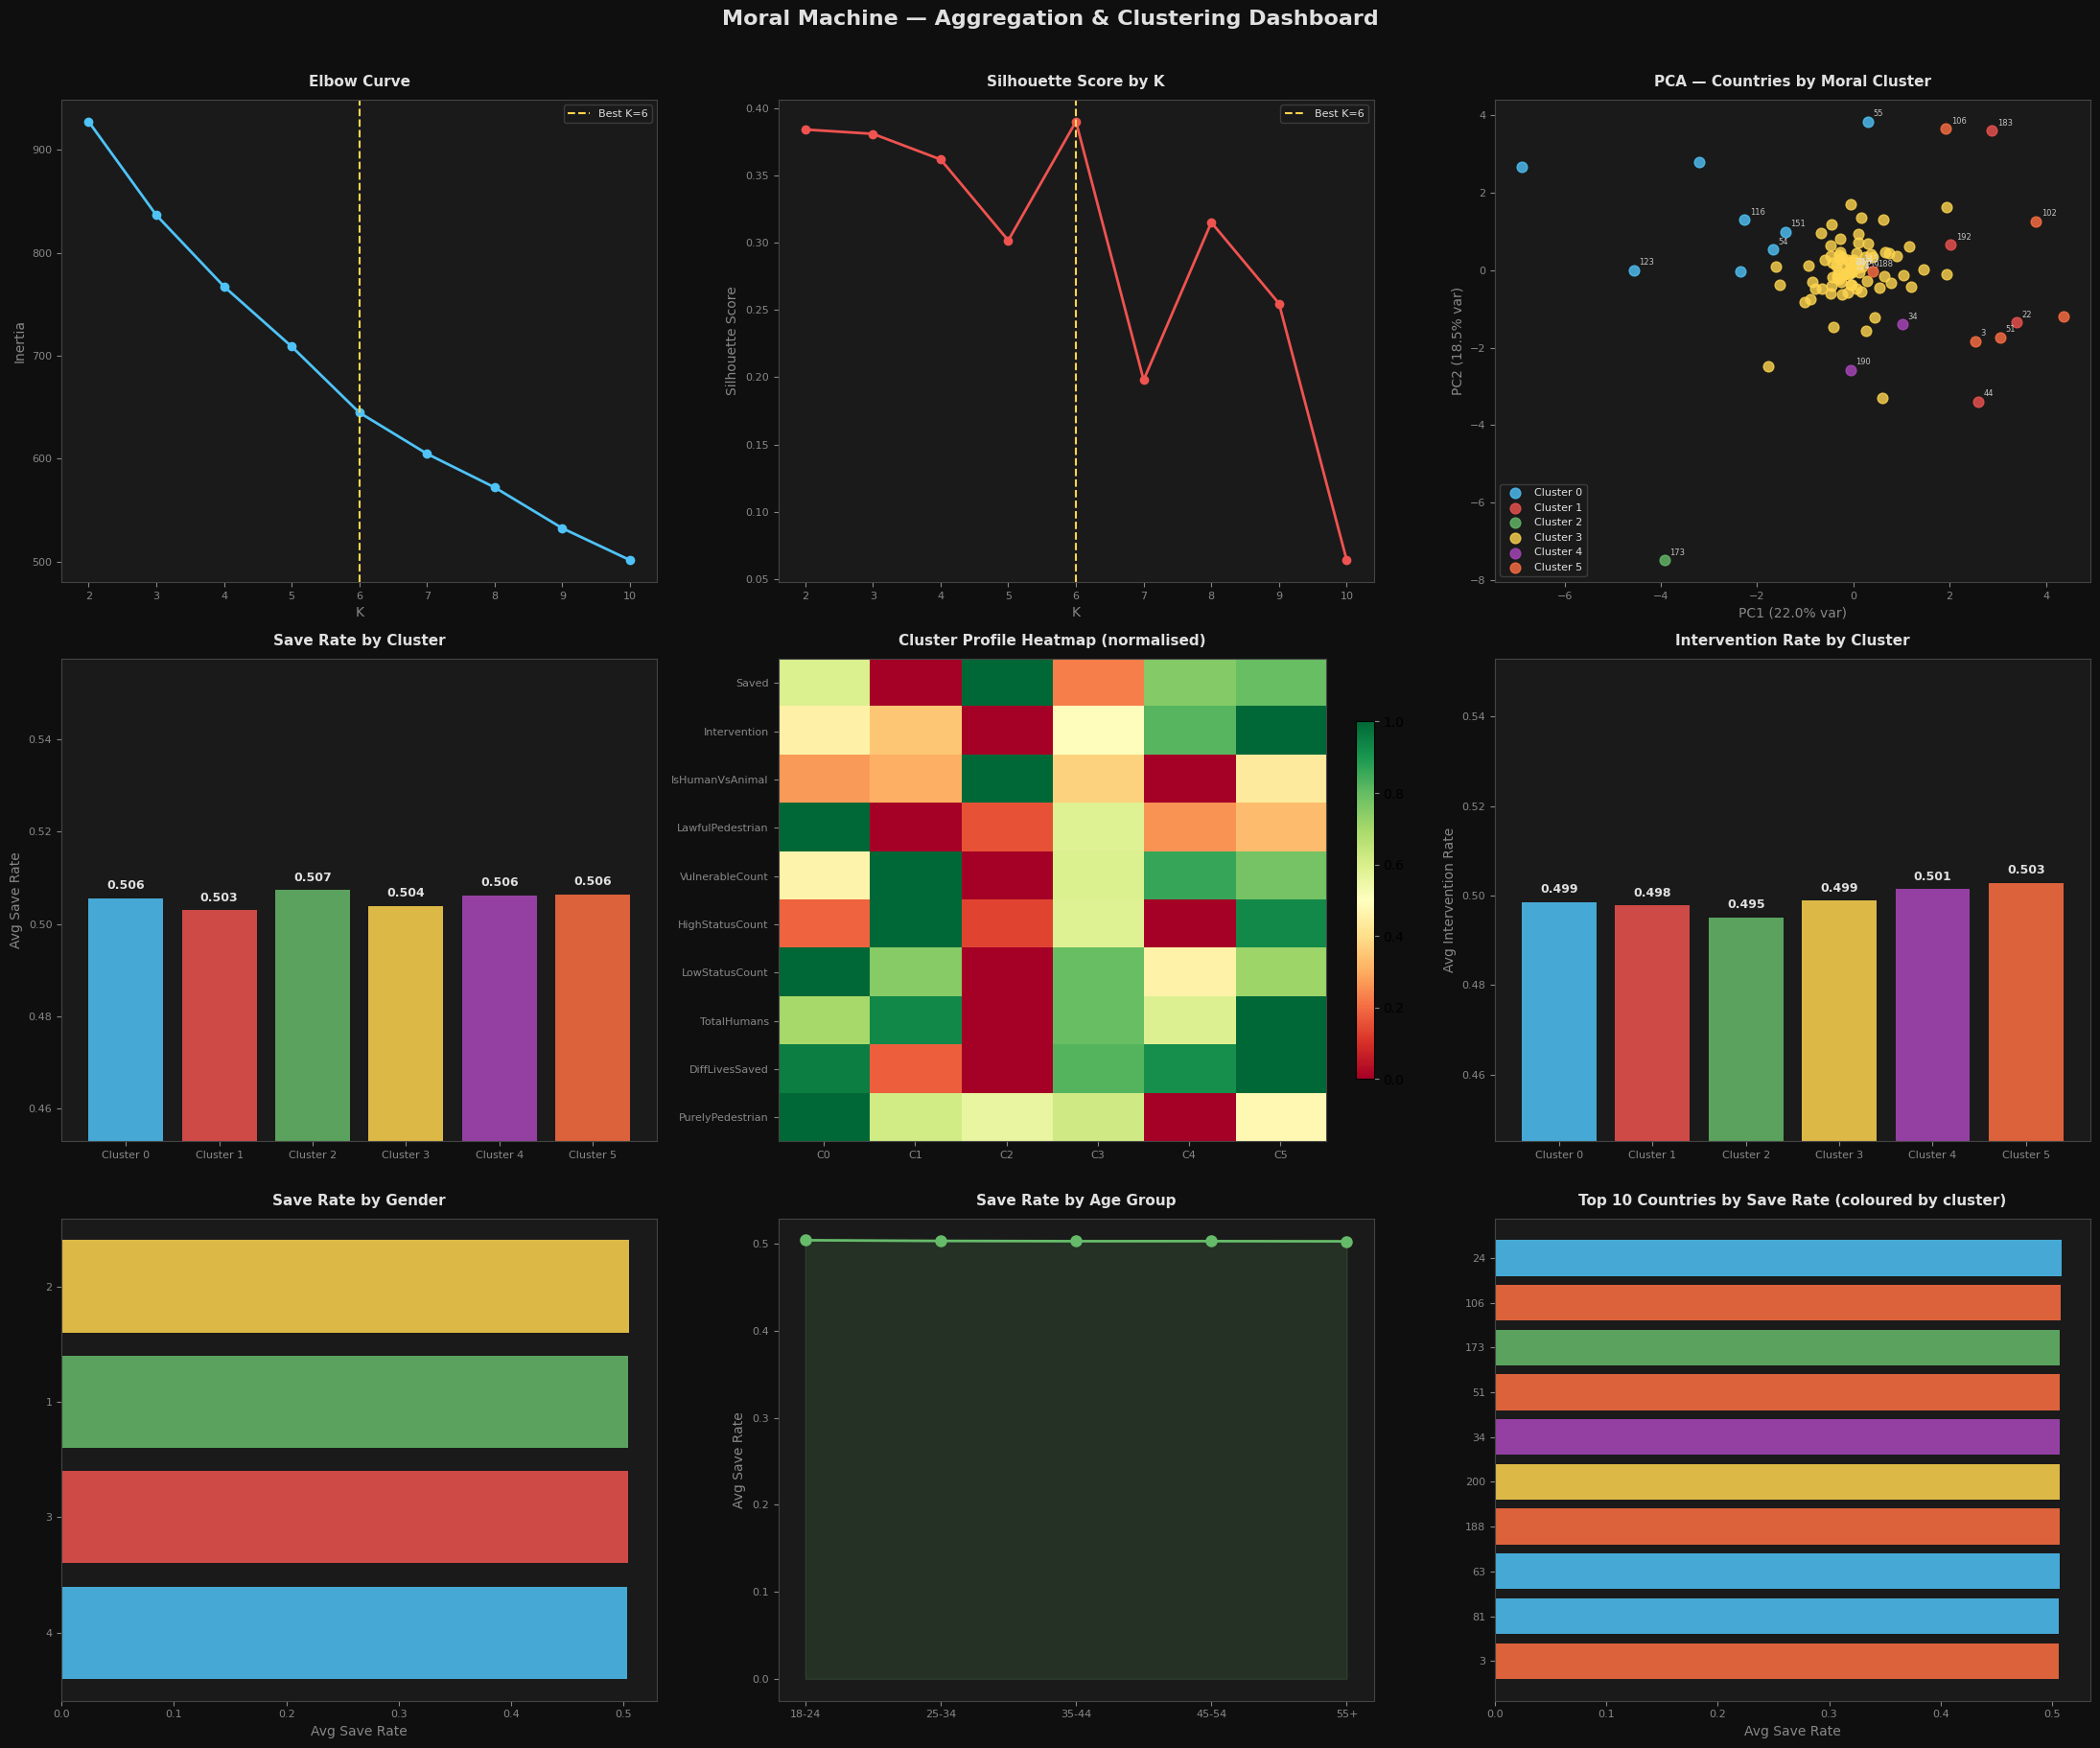


Saved → Images/clustering_analysis.png


In [32]:
print("=" * 60)
print("STEP 6: AGGREGATION & CLUSTERING ANALYSIS")
print("=" * 60)

# ── 1. Rebuild decoded demographic columns from df_encoded ────────────────────
# We need readable labels for aggregation, so decode _enc columns back
# using the label_encoders and ordinal maps stored earlier

label_encoders = {}
nominal_str_cols = ['Review_gender_enc', 'UserCountry3_enc']

for col in nominal_str_cols:
    series = df_feat[col].astype(str).str.strip()
    series = series.replace({'': 'MISSING', 'nan': 'MISSING'})
    le = LabelEncoder()
    le.fit(series)
    label_encoders[col] = le

df_agg = df_feat.copy()

# Decode gender back to string for readable group labels
df_agg['gender_label']    = label_encoders['Review_gender_enc'].inverse_transform(
                                df_agg['Review_gender_enc'].clip(0))
df_agg['country_label']   = label_encoders['UserCountry3_enc'].inverse_transform(
                                df_agg['UserCountry3_enc'].clip(0))

# Bin Review_age_scaled back into readable age groups using original age
# (re-derive from scaled: age = scaled * std + mean)
age_mean = 24.2899
age_std  = 10.6639
df_agg['age_approx'] = (df_agg['Review_age_scaled'] * age_std + age_mean).round()
df_agg['age_group'] = pd.cut(df_agg['age_approx'],
                              bins=[0, 24, 34, 44, 54, 120],
                              labels=['18-24','25-34','35-44','45-54','55+'])

# Bin political score into Low / Moderate / High
df_agg['political_group'] = pd.cut(df_agg['Review_political_scaled'],
                                    bins=[-np.inf, -0.5, 0.5, np.inf],
                                    labels=['Low','Moderate','High'])

# Map education enc back to labels
edu_labels = {0:'underHigh', 1:'high', 2:'vocational', 3:'college',
              4:'bachelor', 5:'graduate', -1:'unknown'}
df_agg['edu_label'] = df_agg['Review_education_enc'].map(edu_labels).fillna('unknown')

# Map income enc back to labels
inc_labels = {0:'<5k', 1:'5k', 2:'10k', 3:'~10k', 4:'15k',
              5:'25k', 6:'35k', 7:'50k', 8:'80k', 9:'>100k', -1:'unknown'}
df_agg['inc_label'] = df_agg['Review_income_enc'].map(inc_labels).fillna('unknown')

# ── 2. Define aggregation feature set ────────────────────────────────────────
# These are the moral preference signals we aggregate per group
agg_features = {
    'Saved'                : 'mean',   # save rate
    'Intervention'         : 'mean',   # tendency to intervene
    'IsHumanVsAnimal'      : 'mean',   # human vs animal scenarios
    'LawfulPedestrian'     : 'mean',   # lawfulness weight
    'VulnerableCount'      : 'mean',   # avg vulnerable chars in saved group
    'HighStatusCount'      : 'mean',   # avg high-status chars in saved group
    'LowStatusCount'       : 'mean',   # avg low-status chars in saved group
    'TotalHumans'          : 'mean',   # avg humans in scenario
    'DiffLivesSaved'       : 'mean',   # avg lives differential
    'PurelyPedestrian'     : 'mean',   # pedestrian-only scenario rate
    'ExtendedSessionID'    : 'count',  # number of decisions (group size)
}

def aggregate_by(df, group_col, label_col=None):
    """Aggregate moral preference features by a demographic group column."""
    col = label_col or group_col
    result = (df.groupby(col)
                .agg(agg_features)
                .reset_index())
    result.columns = [col] + list(agg_features.keys())
    result = result.rename(columns={'ExtendedSessionID': 'n_decisions'})
    result['group_type'] = group_col   # tag which dimension this came from
    result = result.rename(columns={col: 'group_label'})
    # Drop very small groups (fewer than 1000 decisions — unreliable stats)
    result = result[result['n_decisions'] >= 1000].reset_index(drop=True)
    return result

# ── 3. Run aggregations per demographic dimension ─────────────────────────────
agg_country   = aggregate_by(df_agg, 'country',    'country_label')
agg_gender    = aggregate_by(df_agg, 'gender',     'gender_label')
agg_age       = aggregate_by(df_agg, 'age_group')
agg_education = aggregate_by(df_agg, 'education',  'edu_label')
agg_income    = aggregate_by(df_agg, 'income',     'inc_label')
agg_political = aggregate_by(df_agg, 'political',  'political_group')

for name, agg in [('Country', agg_country), ('Gender', agg_gender),
                   ('Age group', agg_age), ('Education', agg_education),
                   ('Income', agg_income), ('Political', agg_political)]:
    print(f"  {name:12s}: {len(agg):>4} groups  |  "
          f"avg decisions/group: {agg['n_decisions'].mean():>10,.0f}")

# Primary clustering target: country (richest + most groups)
df_cluster = agg_country.copy()
print(f"\n  Clustering on: Country aggregation ({len(df_cluster)} countries)")

# ── 4. Prepare cluster matrix ─────────────────────────────────────────────────
cluster_features = ['Saved','Intervention','IsHumanVsAnimal','LawfulPedestrian',
                    'VulnerableCount','HighStatusCount','LowStatusCount',
                    'TotalHumans','DiffLivesSaved','PurelyPedestrian']

X_cluster = df_cluster[cluster_features].values
scaler_c  = StandardScaler()
X_scaled  = scaler_c.fit_transform(X_cluster)

# ── 5. Optimal K via Elbow + Silhouette ───────────────────────────────────────
k_range    = range(2, 11)
inertias   = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

best_k = k_range.start + np.argmax(silhouettes)
print(f"\n  Best K by silhouette score: {best_k}  "
      f"(score={max(silhouettes):.4f})")

# ── 6. Final K-Means fit ──────────────────────────────────────────────────────
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df_cluster['cluster'] = km_final.fit_predict(X_scaled)

# ── 7. PCA for visualization ──────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_cluster['PCA1'] = X_pca[:, 0]
df_cluster['PCA2'] = X_pca[:, 1]
var_explained = pca.explained_variance_ratio_

print(f"  PCA variance explained: PC1={var_explained[0]*100:.1f}%  "
      f"PC2={var_explained[1]*100:.1f}%  "
      f"Total={sum(var_explained)*100:.1f}%")

# ── 8. Cluster profiles ───────────────────────────────────────────────────────
cluster_profiles = (df_cluster.groupby('cluster')[cluster_features]
                               .mean().round(4))
print(f"\n  Cluster profiles (mean values per cluster):")
print(cluster_profiles.to_string())

# ── 9. Visualizations ─────────────────────────────────────────────────────────
DARK   = '#0f0f0f'
PANEL  = '#1a1a1a'
TEXT   = '#e0e0e0'
SUBTEXT = '#888888'
GREY   = '#444444'

palette = ['#4fc3f7','#ef5350','#66bb6a','#ffd54f',
           '#ab47bc','#ff7043','#26c6da','#8d6e63']

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=TEXT, fontsize=11, fontweight='bold', pad=10)
    ax.tick_params(colors=SUBTEXT, labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor(GREY)
    ax.xaxis.label.set_color(SUBTEXT)
    ax.yaxis.label.set_color(SUBTEXT)

fig = plt.figure(figsize=(22, 18))
fig.patch.set_facecolor(DARK)

# ── Panel 1: Elbow curve ──────────────────────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
ax1.plot(list(k_range), inertias, 'o-', color='#4fc3f7', lw=2)
ax1.axvline(best_k, color='#ffd54f', linestyle='--', lw=1.5, label=f'Best K={best_k}')
ax1.set_xlabel('K')
ax1.set_ylabel('Inertia')
ax1.legend(facecolor=PANEL, edgecolor=GREY, labelcolor=TEXT, fontsize=8)
style_ax(ax1, 'Elbow Curve')

# ── Panel 2: Silhouette scores ────────────────────────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)
ax2.plot(list(k_range), silhouettes, 'o-', color='#ef5350', lw=2)
ax2.axvline(best_k, color='#ffd54f', linestyle='--', lw=1.5, label=f'Best K={best_k}')
ax2.set_xlabel('K')
ax2.set_ylabel('Silhouette Score')
ax2.legend(facecolor=PANEL, edgecolor=GREY, labelcolor=TEXT, fontsize=8)
style_ax(ax2, 'Silhouette Score by K')

# ── Panel 3: PCA scatter — countries ─────────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
for c in range(best_k):
    mask = df_cluster['cluster'] == c
    ax3.scatter(df_cluster.loc[mask,'PCA1'], df_cluster.loc[mask,'PCA2'],
                color=palette[c], s=60, alpha=0.8, label=f'Cluster {c}', zorder=3)
    # Label notable countries (top 5 by decisions per cluster)
    top = df_cluster[mask].nlargest(5, 'n_decisions')
    for _, row in top.iterrows():
        ax3.annotate(row['group_label'],
                     (row['PCA1'], row['PCA2']),
                     fontsize=6, color=TEXT, alpha=0.85,
                     xytext=(4, 4), textcoords='offset points')
ax3.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% var)')
ax3.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% var)')
ax3.legend(facecolor=PANEL, edgecolor=GREY, labelcolor=TEXT, fontsize=8)
style_ax(ax3, 'PCA — Countries by Moral Cluster')

# ── Panel 4: Save rate by cluster ────────────────────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
cluster_means = df_cluster.groupby('cluster')['Saved'].mean()
bars = ax4.bar([f'Cluster {i}' for i in cluster_means.index],
               cluster_means.values,
               color=[palette[i] for i in cluster_means.index], alpha=0.85)
for bar, val in zip(bars, cluster_means.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', fontsize=9, color=TEXT, fontweight='bold')
ax4.set_ylabel('Avg Save Rate')
ax4.set_ylim(cluster_means.min() - 0.05, cluster_means.max() + 0.05)
style_ax(ax4, 'Save Rate by Cluster')

# ── Panel 5: Heatmap — cluster profiles ──────────────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)
profile_norm = (cluster_profiles - cluster_profiles.min()) / \
               (cluster_profiles.max() - cluster_profiles.min())
im = ax5.imshow(profile_norm.T.values, aspect='auto', cmap='RdYlGn')
ax5.set_xticks(range(best_k))
ax5.set_xticklabels([f'C{i}' for i in range(best_k)], color=TEXT, fontsize=9)
ax5.set_yticks(range(len(cluster_features)))
ax5.set_yticklabels(cluster_features, color=TEXT, fontsize=8)
plt.colorbar(im, ax=ax5, fraction=0.03).ax.yaxis.set_tick_params(color=SUBTEXT)
style_ax(ax5, 'Cluster Profile Heatmap (normalised)')

# ── Panel 6: Intervention rate by cluster ────────────────────────────────────
ax6 = fig.add_subplot(3, 3, 6)
cluster_int = df_cluster.groupby('cluster')['Intervention'].mean()
bars2 = ax6.bar([f'Cluster {i}' for i in cluster_int.index],
                cluster_int.values,
                color=[palette[i] for i in cluster_int.index], alpha=0.85)
for bar, val in zip(bars2, cluster_int.values):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', fontsize=9, color=TEXT, fontweight='bold')
ax6.set_ylabel('Avg Intervention Rate')
ax6.set_ylim(cluster_int.min() - 0.05, cluster_int.max() + 0.05)
style_ax(ax6, 'Intervention Rate by Cluster')

# ── Panel 7: Save rate by gender ─────────────────────────────────────────────
ax7 = fig.add_subplot(3, 3, 7)
gender_save = agg_gender.set_index('group_label')['Saved'].sort_values()
colors_g = [palette[i % len(palette)] for i in range(len(gender_save))]
ax7.barh(gender_save.index, gender_save.values, color=colors_g, alpha=0.85)
ax7.set_xlabel('Avg Save Rate')
style_ax(ax7, 'Save Rate by Gender')

# ── Panel 8: Save rate by age group ──────────────────────────────────────────
ax8 = fig.add_subplot(3, 3, 8)
age_save = agg_age.set_index('group_label')['Saved'].reindex(
    ['18-24','25-34','35-44','45-54','55+'])
ax8.plot(age_save.index, age_save.values, 'o-', color='#66bb6a', lw=2, ms=8)
ax8.fill_between(age_save.index, age_save.values,
                 alpha=0.15, color='#66bb6a')
ax8.set_ylabel('Avg Save Rate')
style_ax(ax8, 'Save Rate by Age Group')

# ── Panel 9: Top 10 countries by save rate ────────────────────────────────────
ax9 = fig.add_subplot(3, 3, 9)
top10 = df_cluster.nlargest(10, 'Saved')[['group_label','Saved','cluster']]
colors_t = [palette[c] for c in top10['cluster']]
ax9.barh(top10['group_label'], top10['Saved'], color=colors_t, alpha=0.85)
ax9.set_xlabel('Avg Save Rate')
ax9.invert_yaxis()
style_ax(ax9, 'Top 10 Countries by Save Rate (coloured by cluster)')

fig.suptitle('Moral Machine — Aggregation & Clustering Dashboard',
             color=TEXT, fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(path + 'clustering_analysis.png', dpi=150, bbox_inches='tight',
            facecolor=DARK)
plt.show()
print(f"\nSaved → {path}clustering_analysis.png")